## Generate platemap figures

Create a figure of the 384-well layout for each plate (similar to the `platetools` plate maps in R).
In each figure:

- **Fill colour** is the seeding density (cells/well)
- **Marker shape** is the plate coating
- **Text label** is the cell line, centred on each group of adjacent wells
- **Media only** wells (imaged wells that are not in the platemap, so they have no cells) are drawn as filled grey circles
- **Empty** wells (wells that were not imaged) are drawn as hollow grey circles

The Excel file labels every well without cells as "media", so it can not be used to separate media only wells from empty wells.
Instead, the wells that were imaged are taken from the LoadData CSVs (generated in `1.whole_image_qc`).

Each figure is saved as a PNG and all figures are also saved to one PDF (one page per plate).

In [1]:
import pathlib
import string

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

In [2]:
# Directory with the platemap CSVs (generated by generate_platemaps_from_xlsx.ipynb)
platemap_dir = pathlib.Path("./platemaps")

# Directory with the LoadData CSVs, used to find which wells were imaged on each plate
loaddata_dir = pathlib.Path("../../1.whole_image_qc/loaddata_csvs")

# Output for platemap figures
output_dir = pathlib.Path("./platemap_figures")
output_dir.mkdir(exist_ok=True)

# Layout of a 384-well plate
plate_rows = list(string.ascii_uppercase[:16])
plate_columns = list(range(1, 25))

# Fill colour per seeding density (one hue, light to dark)
density_colors = {
    1000: "#86b6ef",
    2000: "#5598e7",
    4000: "#2a78d6",
    8000: "#1c5cab",
    12000: "#0d366b",
}

# Marker shape per plate coating
coating_markers = {"standard": "o", "laminin": "s", "synthemax": "^"}

# Increase the resolution of the figures displayed in the notebook
plt.rcParams["figure.dpi"] = 200

In [3]:
def plot_platemap(
    platemap: pd.DataFrame,
    media_only_wells: list[str],
    output_file: pathlib.Path,
    pdf: PdfPages,
) -> None:
    """Plot a 384-well platemap figure for one plate, save it as a PNG, and add it as a page to the PDF.

    Args:
        platemap (pd.DataFrame): platemap for one plate (one row per well)
        media_only_wells (list[str]): well positions (e.g., C09) that were imaged but have no cells
        output_file (pathlib.Path): path to save the PNG figure to
        pdf (PdfPages): open PDF to add the figure to as a new page
    """
    platemap = platemap.copy()

    # Plot coordinates per well (row A at the top)
    platemap["x"] = platemap["column"]
    platemap["y"] = platemap["row"].map({row: i for i, row in enumerate(plate_rows)})

    # Lowercase the coating to match the keys of the marker dictionary
    platemap["plate_coating"] = platemap["plate_coating"].str.lower()
    platemap["seeding_density"] = platemap["seeding_density"].astype(int)

    fig, ax = plt.subplots(figsize=(18, 10.5))

    # Draw every well on the plate as hollow so the full plate layout is visible
    ax.scatter(
        [col for _ in plate_rows for col in plate_columns],
        [i for i, _ in enumerate(plate_rows) for _ in plate_columns],
        s=1100,
        facecolors="none",
        edgecolors="#c3c2b7",
        linewidths=1,
    )

    # Fill in the media only wells in grey (all remaining hollow wells are empty)
    ax.scatter(
        [int(well[1:]) for well in media_only_wells],
        [plate_rows.index(well[0]) for well in media_only_wells],
        s=1100,
        facecolors="#d9d8d2",
        edgecolors="#c3c2b7",
        linewidths=1,
    )

    # Draw the wells in the platemap (fill = seeding density, shape = plate coating)
    for coating, marker in coating_markers.items():
        wells = platemap[platemap["plate_coating"] == coating]
        ax.scatter(
            wells["x"],
            wells["y"],
            # Squares fill more of the well than the other shapes, so draw them smaller
            s=800 if marker == "s" else 1100,
            marker=marker,
            c=wells["seeding_density"].map(density_colors),
            edgecolors="white",
            linewidths=1,
        )

    # Label each group of adjacent wells from the same cell line and plate coating
    # (a cell line can be in more than one spot on a plate, so split the wells into
    # separate groups wherever there is a gap in the columns or in the rows)
    for _, condition_wells in platemap.groupby(["cell_line", "plate_coating"]):
        column_block = condition_wells["x"].map(
            (condition_wells["x"].drop_duplicates().sort_values().diff() > 1)
            .cumsum()
            .set_axis(condition_wells["x"].drop_duplicates().sort_values())
        )
        row_block = condition_wells["y"].map(
            (condition_wells["y"].drop_duplicates().sort_values().diff() > 1)
            .cumsum()
            .set_axis(condition_wells["y"].drop_duplicates().sort_values())
        )
        for _, wells in condition_wells.groupby([column_block, row_block]):
            ax.text(
                wells["x"].mean(),
                wells["y"].mean(),
                wells["cell_line"].iloc[0],
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color="#0b0b0b",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9),
            )

    # Format plate axes (column numbers on top, row letters on the left)
    ax.set_xticks(plate_columns)
    ax.set_yticks(range(len(plate_rows)), labels=plate_rows)
    ax.xaxis.tick_top()
    ax.tick_params(length=0, labelsize=12, colors="#52514e")
    ax.set_xlim(0.3, 24.7)
    ax.set_ylim(len(plate_rows) - 0.3, -0.7)
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Legends only include the levels present on this plate
    density_handles = [
        Line2D([], [], marker="o", ls="", ms=14, mfc=color, mec="white", label=f"{density:,}")
        for density, color in density_colors.items()
        if density in platemap["seeding_density"].unique()
    ]
    coating_handles = [
        Line2D([], [], marker=marker, ls="", ms=14, mfc="#898781", mec="white", label=coating.capitalize())
        for coating, marker in coating_markers.items()
        if coating in platemap["plate_coating"].unique()
    ]
    density_legend = ax.legend(
        handles=density_handles,
        title="Seeding density\n(cells/well)",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        frameon=False,
        fontsize=12,
        title_fontsize=12,
        labelspacing=0.8,
        alignment="left",
    )
    ax.add_artist(density_legend)

    # Place the coating legend directly below the density legend (the height of the
    # density legend depends on how many densities are on the plate)
    fig.canvas.draw()
    density_legend_bottom = (
        density_legend.get_window_extent().transformed(ax.transAxes.inverted()).y0
    )
    coating_legend = ax.legend(
        handles=coating_handles,
        title="Plate coating",
        loc="upper left",
        bbox_to_anchor=(1.01, density_legend_bottom - 0.03),
        frameon=False,
        fontsize=12,
        title_fontsize=12,
        labelspacing=0.8,
        alignment="left",
    )

    ax.add_artist(coating_legend)

    # Add a key for the wells without cells below the coating legend
    fig.canvas.draw()
    coating_legend_bottom = (
        coating_legend.get_window_extent().transformed(ax.transAxes.inverted()).y0
    )
    ax.legend(
        handles=[
            Line2D([], [], marker="o", ls="", ms=14, mfc="#d9d8d2", mec="#c3c2b7", label="Media only"),
            Line2D([], [], marker="o", ls="", ms=14, mfc="none", mec="#c3c2b7", label="Empty"),
        ],
        title="No cells",
        loc="upper left",
        bbox_to_anchor=(1.01, coating_legend_bottom - 0.03),
        frameon=False,
        fontsize=12,
        title_fontsize=12,
        labelspacing=0.8,
        alignment="left",
    )

    # Title with the plate level metadata
    plate_barcode = platemap["plate_barcode"].iloc[0]
    time_point = platemap["time_point"].iloc[0]
    pfa_fixation = platemap["pfa_fixation"].iloc[0]
    ax.set_title(
        f"{plate_barcode} | {time_point} hours | {pfa_fixation} PFA fixation | "
        f"{platemap['cell_line'].nunique()} cell lines",
        fontsize=16,
        fontweight="bold",
        loc="left",
        pad=30,
    )

    fig.savefig(output_file, dpi=600, bbox_inches="tight", pad_inches=0.3, facecolor="white")
    pdf.savefig(fig, bbox_inches="tight", pad_inches=0.3, facecolor="white")
    plt.show()
    plt.close(fig)

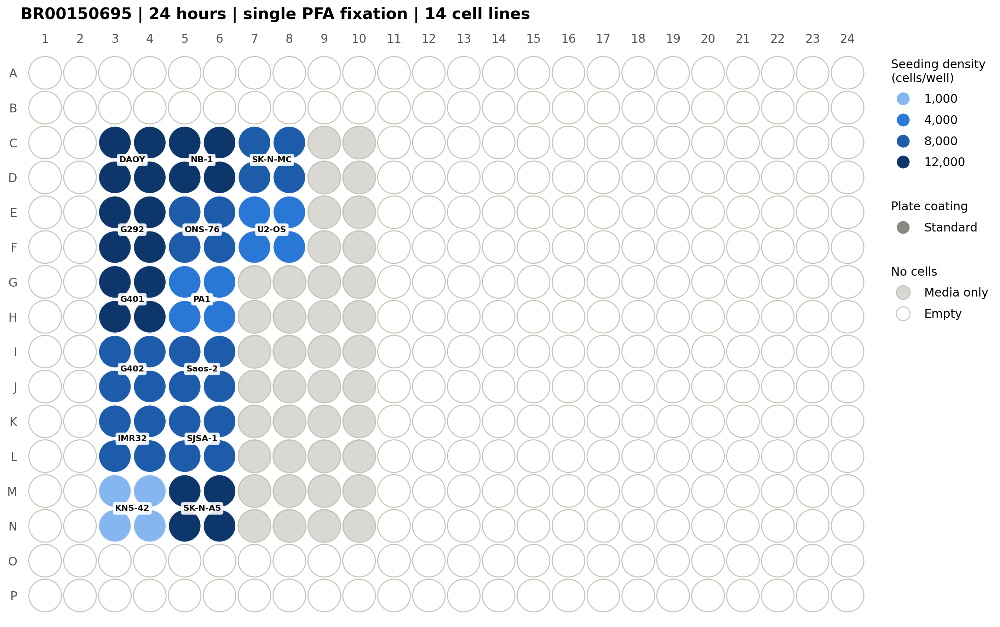

BR00150695: 56 wells with cells, 40 media only wells
Saved platemap_figures/BR00150695_platemap_figure.png


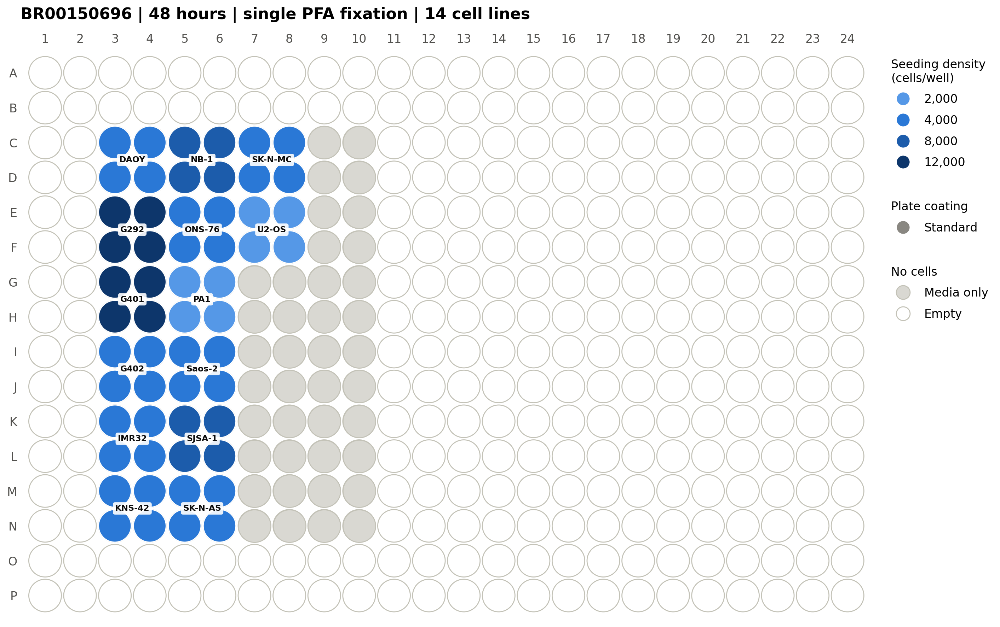

BR00150696: 56 wells with cells, 40 media only wells
Saved platemap_figures/BR00150696_platemap_figure.png


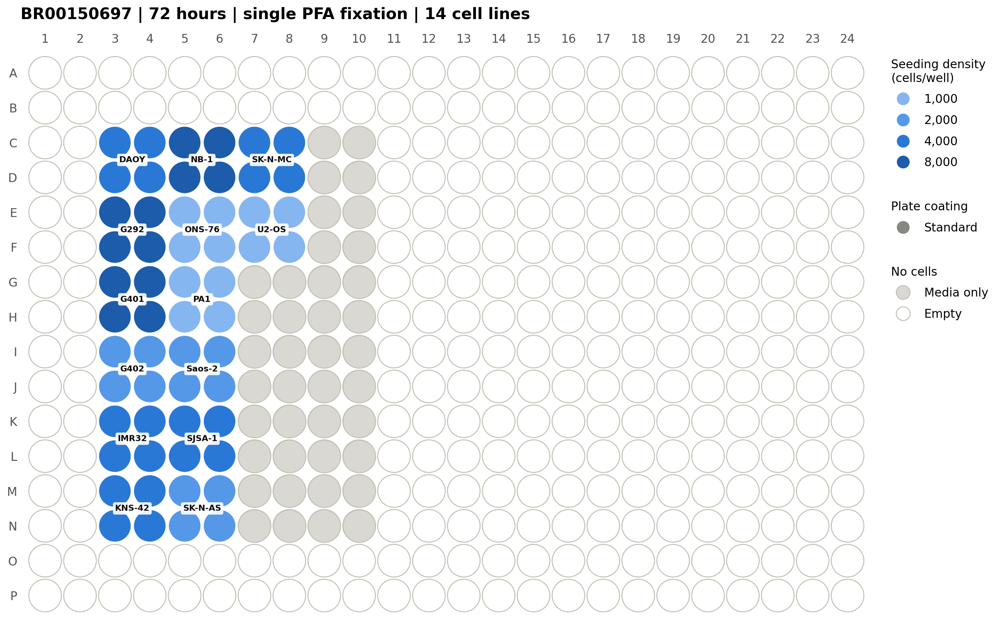

BR00150697: 56 wells with cells, 40 media only wells
Saved platemap_figures/BR00150697_platemap_figure.png


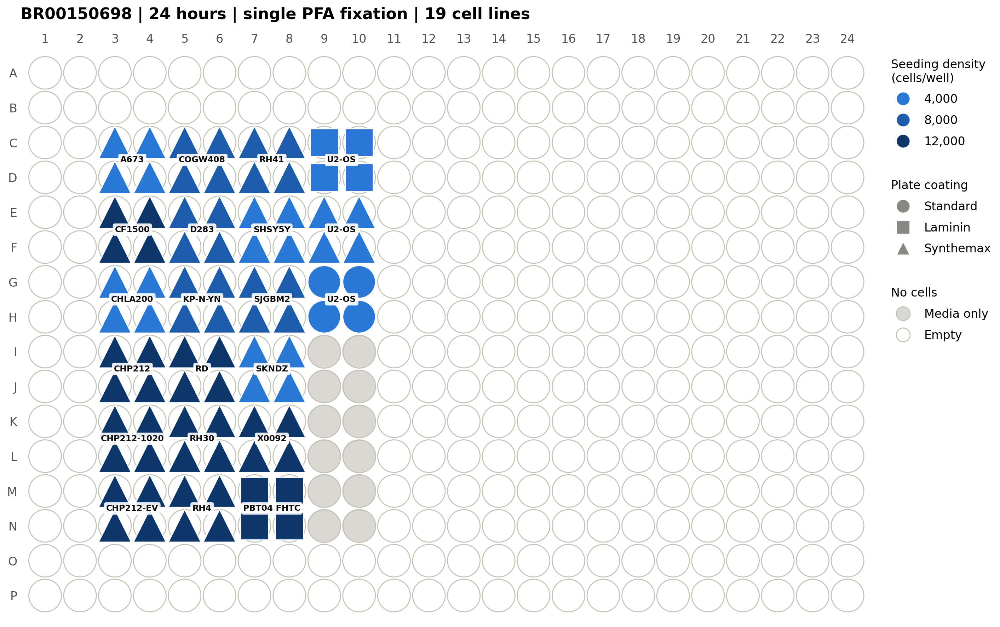

BR00150698: 84 wells with cells, 12 media only wells
Saved platemap_figures/BR00150698_platemap_figure.png


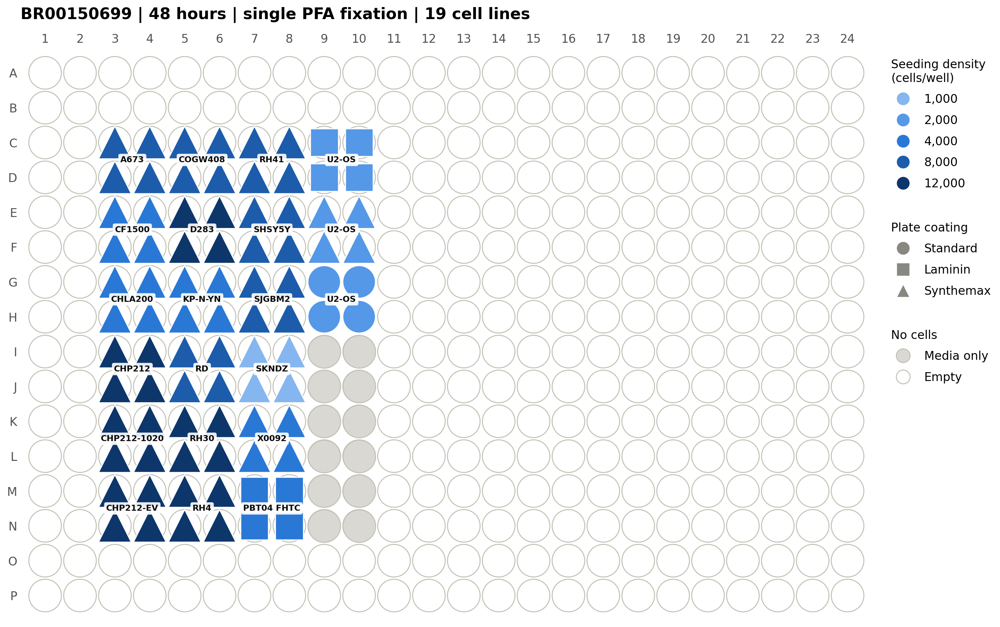

BR00150699: 84 wells with cells, 12 media only wells
Saved platemap_figures/BR00150699_platemap_figure.png


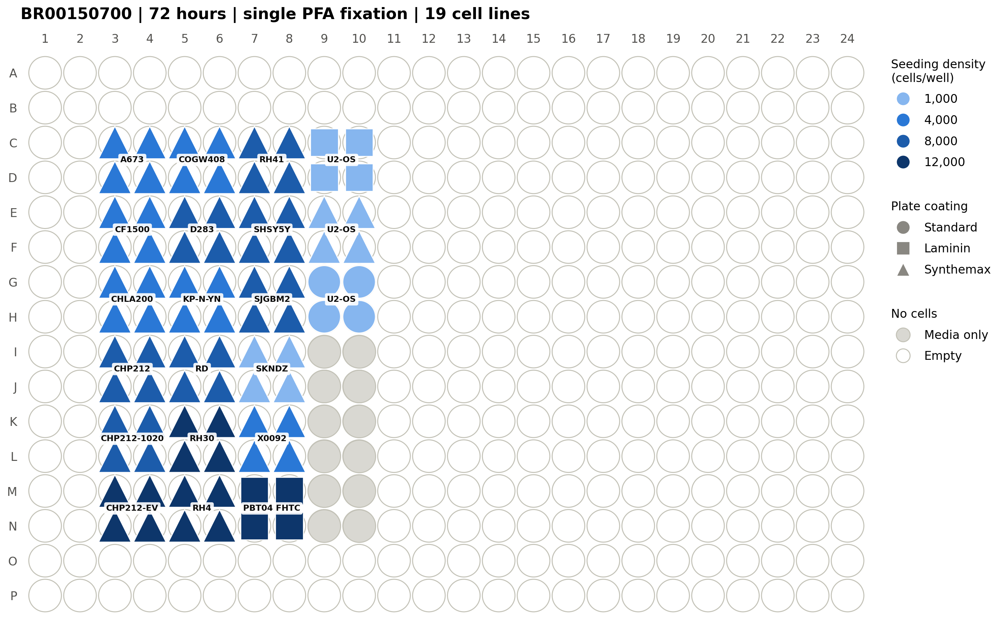

BR00150700: 84 wells with cells, 12 media only wells
Saved platemap_figures/BR00150700_platemap_figure.png


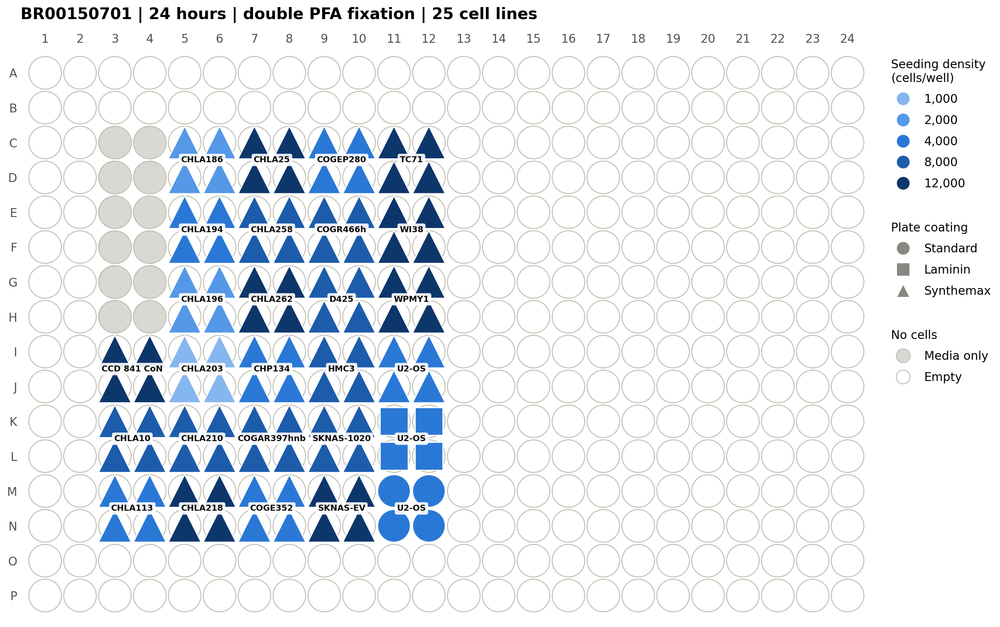

BR00150701: 108 wells with cells, 12 media only wells
Saved platemap_figures/BR00150701_platemap_figure.png


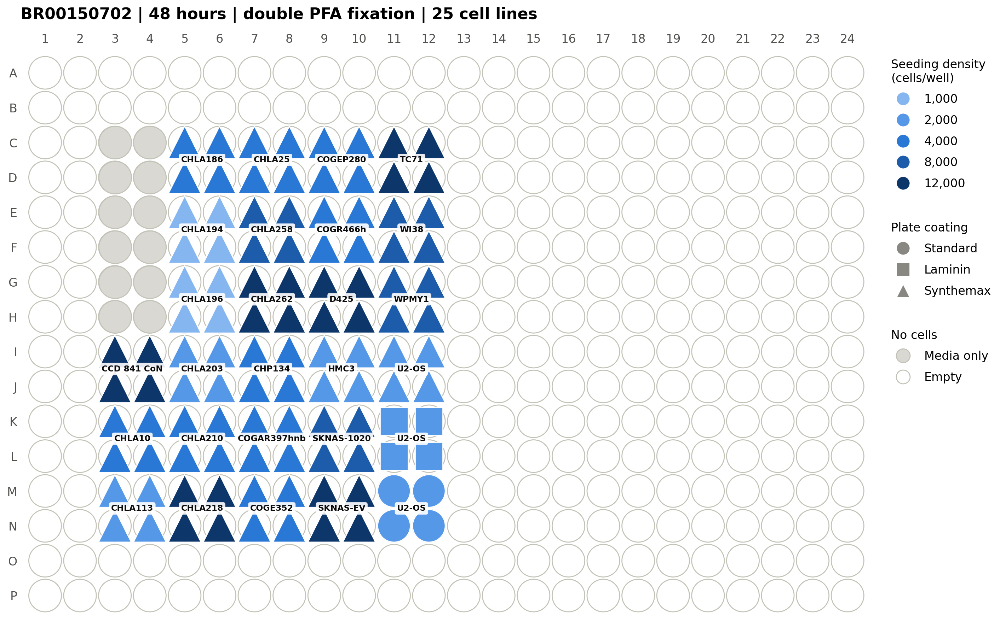

BR00150702: 108 wells with cells, 12 media only wells
Saved platemap_figures/BR00150702_platemap_figure.png


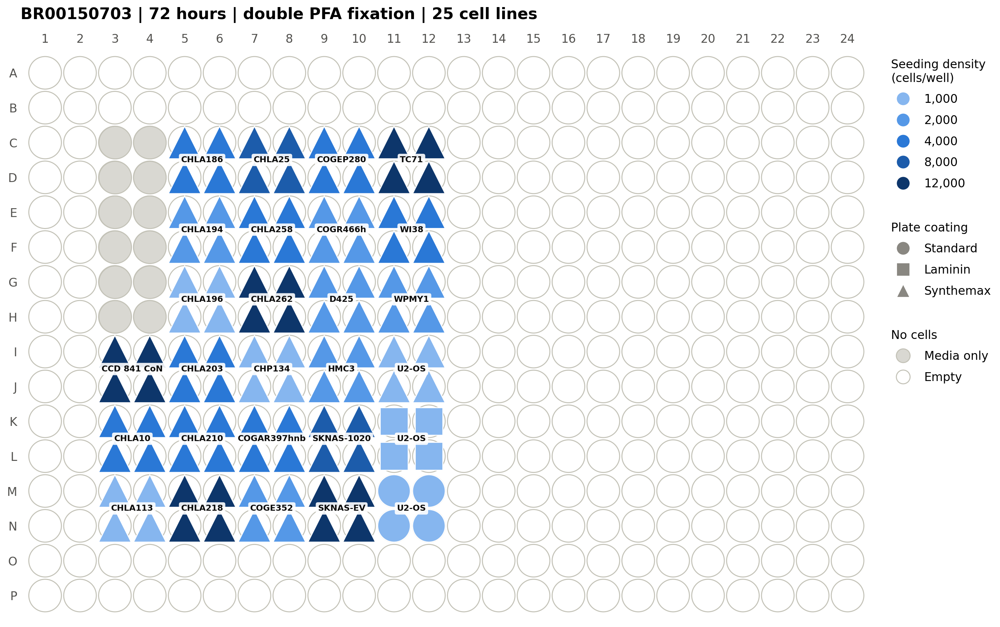

BR00150703: 108 wells with cells, 12 media only wells
Saved platemap_figures/BR00150703_platemap_figure.png
Saved platemap_figures/all_platemap_figures.pdf


In [4]:
# Generate one figure per platemap and collect all figures into one PDF (one page per plate)
pdf_file = output_dir / "all_platemap_figures.pdf"
pdf = PdfPages(pdf_file)

for platemap_file in sorted(platemap_dir.glob("*_platemap.csv")):
    platemap = pd.read_csv(platemap_file)

    # Each platemap should only contain one plate, time point, and fixation
    for col in ["plate_barcode", "time_point", "pfa_fixation"]:
        if platemap[col].nunique() != 1:
            raise ValueError(
                f"Expected one {col} in {platemap_file} but found: {platemap[col].unique()}"
            )

    # Confirm every well has a colour and marker assigned before plotting
    unknown_densities = set(platemap["seeding_density"].astype(int)) - set(density_colors)
    unknown_coatings = set(platemap["plate_coating"].str.lower()) - set(coating_markers)
    if unknown_densities or unknown_coatings:
        raise ValueError(
            f"Unexpected values in {platemap_file}: {unknown_densities} {unknown_coatings}"
        )

    # Media only wells are the wells that were imaged but are not in the platemap
    plate_barcode = platemap["plate_barcode"].iloc[0]
    imaged_wells = set(
        pd.read_csv(
            loaddata_dir / f"{plate_barcode}_loaddata.csv", usecols=["Metadata_Well"]
        )["Metadata_Well"]
    )
    cell_wells = set(platemap["well_position"])
    if not cell_wells.issubset(imaged_wells):
        raise ValueError(
            f"Wells in {platemap_file} were not imaged: {sorted(cell_wells - imaged_wells)}"
        )
    media_only_wells = sorted(imaged_wells - cell_wells)

    output_file = output_dir / f"{platemap_file.stem}_figure.png"
    plot_platemap(
        platemap=platemap,
        media_only_wells=media_only_wells,
        output_file=output_file,
        pdf=pdf,
    )

    print(f"{plate_barcode}: {len(cell_wells)} wells with cells, {len(media_only_wells)} media only wells")

    print(f"Saved {output_file}")

pdf.close()
print(f"Saved {pdf_file}")